# Supervised Learning: Heart Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


Matplotlib is building the font cache; this may take a moment.


## 1. Data Loading and Inspection

In [2]:
df = pd.read_csv('q1_heart_disease.csv')

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())

df.head()


Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## 2. Exploratory Data Analysis

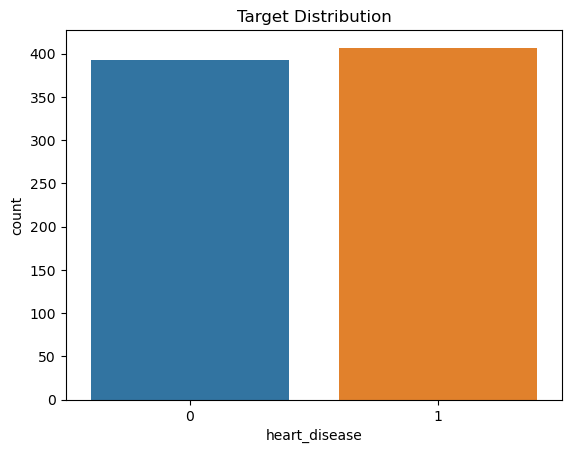

In [3]:
# Target distribution
sns.countplot(x='heart_disease', data=df)
plt.title("Target Distribution")
plt.show()


Interpretation: This shows whether the dataset is balanced or imbalanced between disease and no disease.

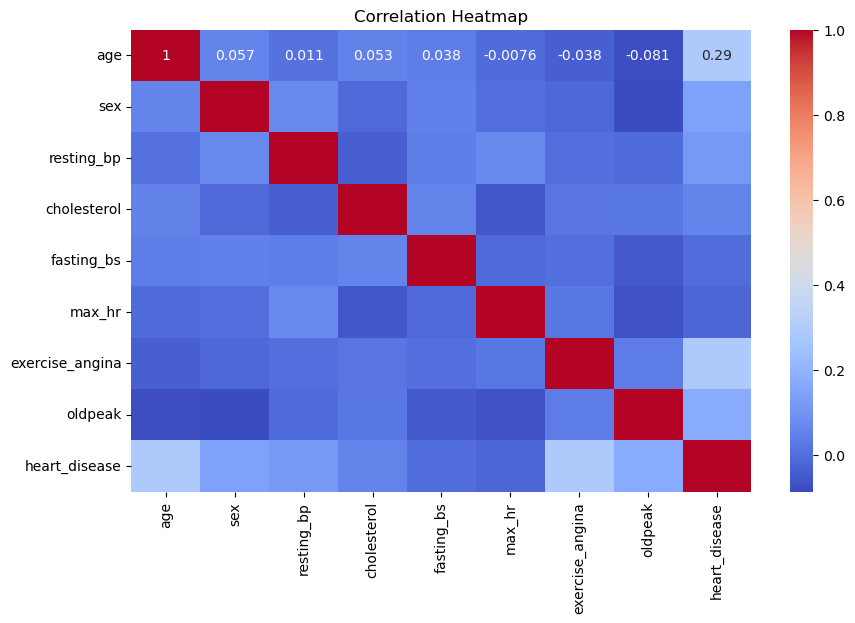

In [4]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Interpretation: This helps identify relationships between features and the target.

C:\Users\Tanvesh Rongala\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


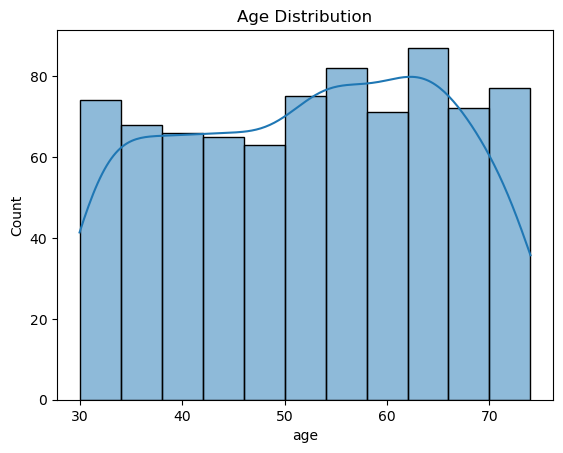

In [5]:
# Age distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()


Interpretation: Shows how patient ages are distributed.

## 3. Data Preprocessing

In [6]:
# Handle missing values
df = df.fillna(df.median(numeric_only=True))

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', 'passthrough', categorical_cols)
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


Interpretation: Missing values handled using median imputation. Features are scaled and dataset split with stratification.

## 4. Model Training

In [7]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

trained_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe


ValueError: could not convert string to float: 'non_anginal'

## 5. Model Evaluation

In [ ]:
for name, model in trained_models.items():
    print(f"\n{name}")
    y_pred = model.predict(X_test)

    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))


Interpretation: Compare Precision, Recall, and F1-score to determine best model.

## 6. Hyperparameter Tuning

In [ ]:
# Example tuning on Random Forest

param_grid = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [None, 5, 10]
}

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1')
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

y_pred = grid.predict(X_test)
print("\nTuned Model Report:\n", classification_report(y_test, y_pred))


Interpretation: Compare tuned vs baseline model performance.